# Dermoscopic Lesion Segmentation: Comparing Three Classical Methods

This notebook walks through the full pipeline of the project and compares three
non-learning segmentation methods on dermoscopic images of skin lesions:

1. **Multi-channel Otsu** thresholding, refined by a Chan-Vese active contour
2. **LBP Clustering**, after Pereira et al. (2020)
3. **Statistical Region Merging**, after Celebi et al. (2008)

All the algorithms live in the `dermoseg` package under `src/`. This notebook
only calls them and draws the results, so the code shown here stays readable
and the notebook cannot drift away from what the benchmark script runs.

## Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from dermoseg import postprocessing, visualization as viz
from dermoseg.data import iter_samples, load_sample
from dermoseg.pipeline import METHODS, run_all_methods
from dermoseg.preprocessing import preprocess_with_mask
from dermoseg.segmentation import lbp, otsu, region_merging

plt.rcParams["figure.dpi"] = 90
print("methods:", ", ".join(METHODS))

methods: Otsu, LBP, SRM


## 1. The dataset

Twenty dermoscopic images from the ISIC archive, ten melanomas and ten nevi,
each paired with an expert-drawn segmentation mask used as ground truth.

The pairing is what makes the comparison quantitative: every predicted mask is
scored against the expert's with the Dice coefficient.

20 images
melanoma    10
nevus       10


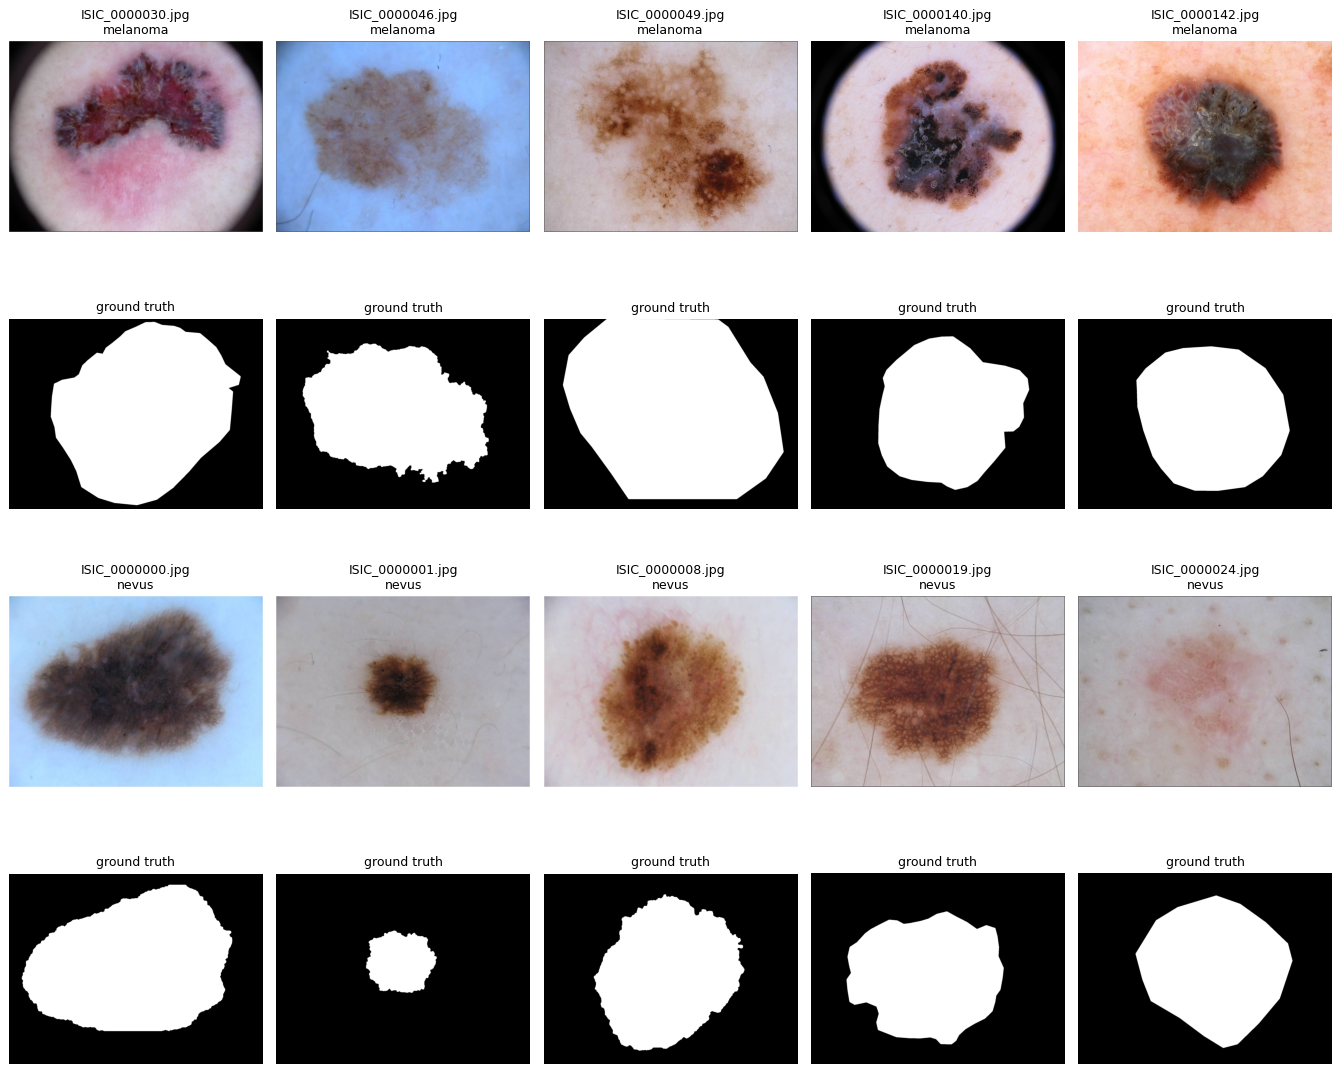

In [2]:
samples = list(iter_samples())
print(f"{len(samples)} images")
print(pd.Series([s.category for s in samples]).value_counts().to_string())

figure = viz.plot_dataset_overview(samples[:5] + samples[10:15])
plt.show()

## 2. Preprocessing

Two artefacts have to go before any segmenter sees the image.

**The dermoscope frame.** The instrument images the skin through a circular
lens, so the corners of many ISIC images are black. No intensity-based method
can tell a black corner from a dark lesion, so the disc is detected and the
outside is whitened and cropped away.

**Hair.** Dark elongated structures crossing the lesion border break both the
thresholds and the region merging. Following DullRazor, hairs are found by
grayscale closing with elongated structuring elements (a closing with an
element wider than a hair erases it, so the difference reveals it), then
inpainted from the surrounding skin.

Images with little hair are left untouched: inpainting a clean image only
blurs the border we are trying to find.

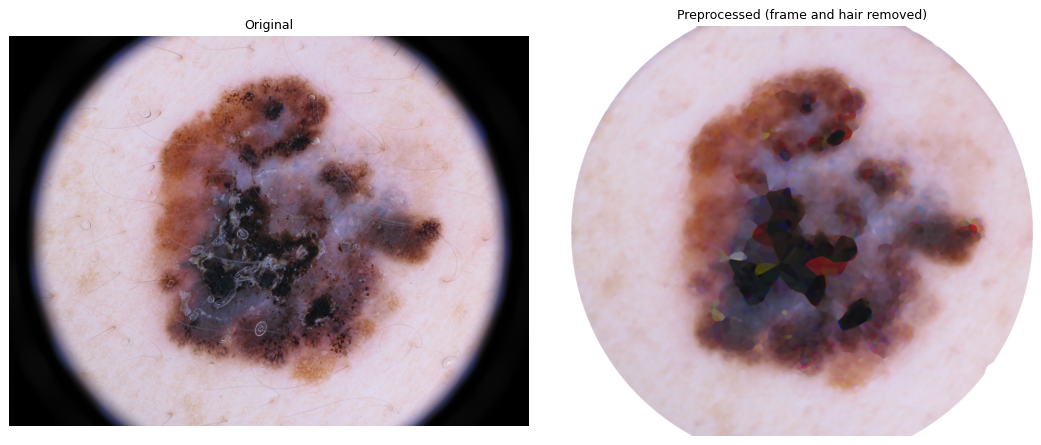

original (2112, 2816, 3) -> preprocessed (2112, 2379, 3)
valid (inside the dermoscope disc): 84.5% of pixels


In [3]:
sample = load_sample(ROOT / "data" / "melanoma" / "ISIC_0000140.jpg")
image, valid_mask = preprocess_with_mask(sample.image)

figure = viz.plot_preprocessing(sample.image, image)
plt.show()

print(f"original {sample.image.shape} -> preprocessed {image.shape}")
print(f"valid (inside the dermoscope disc): {valid_mask.mean():.1%} of pixels")

## 3. Method 1: Multi-channel Otsu

Otsu's threshold is computed independently on R, G and B. A lesion is darker
than skin in all three, but blue carries the strongest melanin contrast, so
the channels are combined as `(R and G) or B`: a pixel is lesion when red
*and* green agree, or when blue alone is confident.

That mask has ragged borders, so it seeds a Chan-Vese active contour which
relaxes onto the real intensity boundary.

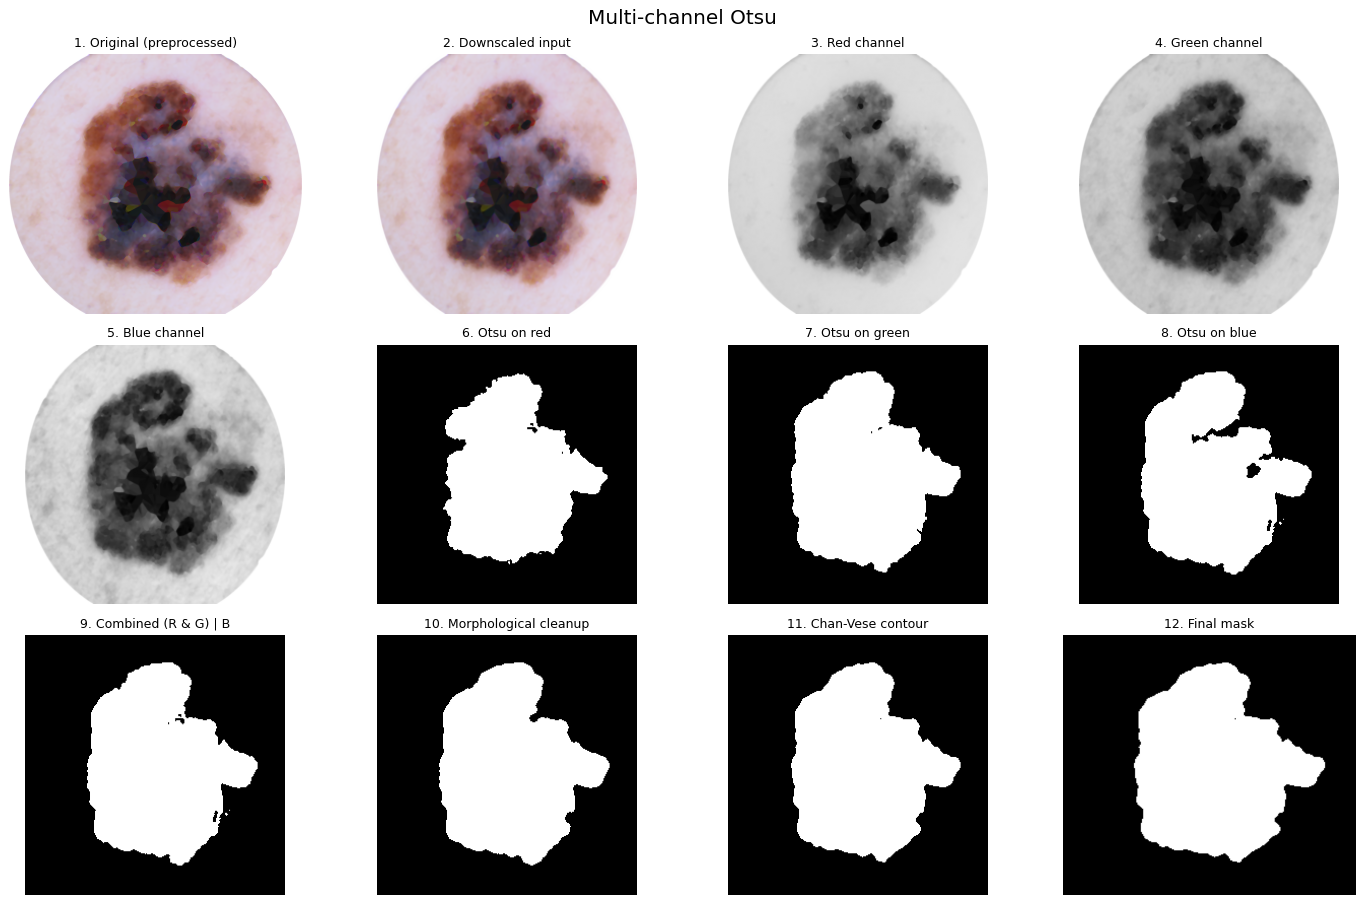

{'red': 0.63, 'green': 0.553, 'blue': 0.578}


In [4]:
result_otsu = otsu.segment(image)
figure = viz.plot_pipeline(result_otsu, title="Multi-channel Otsu", original=image)
plt.show()

print({name: round(value, 3) for name, value in result_otsu.info["thresholds"].items()})

## 4. Method 2: LBP Clustering

The assumption is textural: lesion skin is busier than healthy skin.

Local Binary Patterns with P=8 neighbours at radius R=1 label each pixel by the
sign pattern of its neighbourhood. The flat patterns (code 0, and the eight
powers of two, meaning a single brighter neighbour) mark smooth skin;
everything else marks texture. Binarising on that subset gives a texture map,
which is smoothed into a continuous field L.

L is then stacked with the luminance Y into a synthetic image `[L, Y, L]` and
converted to CIE L\*a\*b\*. Clustering the (a\*, b\*) chromaticity of *that*
image separates lesion from skin, and the **pinkness** score
`max(a*, 0) - min(b*, 0)` picks which of the two clusters is the lesion, with
no training and no labels.

One caveat specific to cropped images: the whitened corners turn pure green in
the pseudo-RGB, an extreme in (a\*, b\*). Left in, they would capture a cluster
outright and k-means would separate disc from corners rather than lesion from
skin, so the fit is restricted to the valid area.

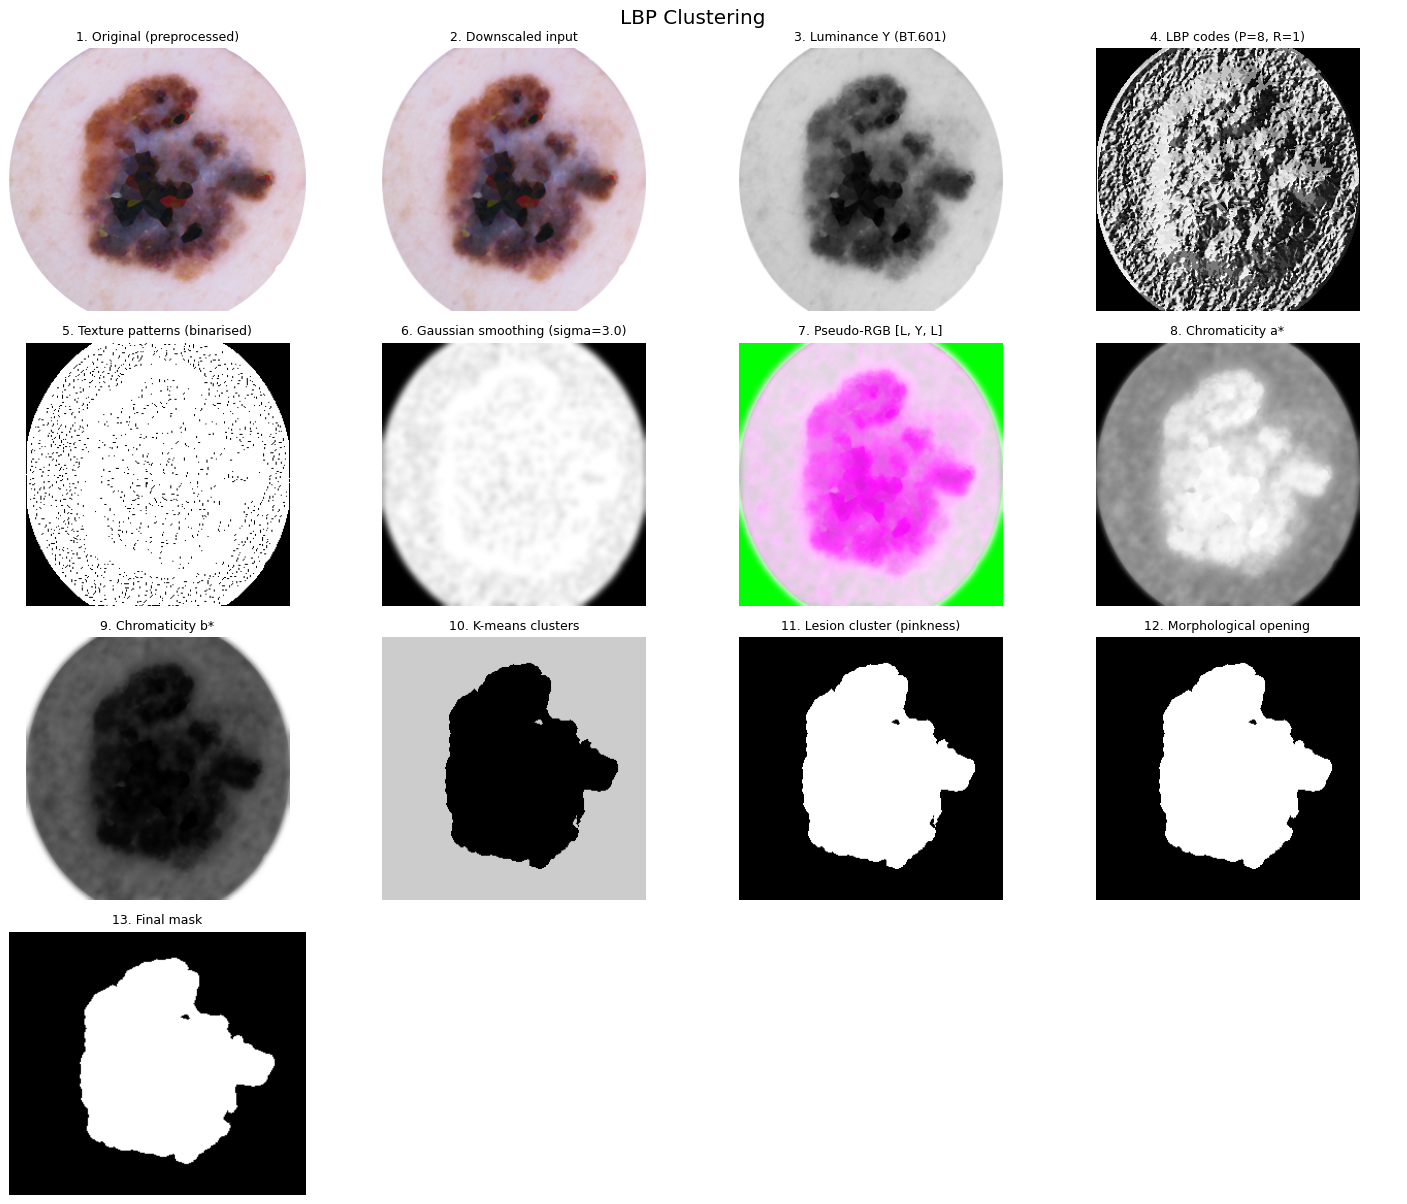

pinkness per cluster: [126.6, 31.0] -> lesion is cluster 0


In [5]:
result_lbp = lbp.segment(image, sigma=3.0, valid_mask=valid_mask)
figure = viz.plot_pipeline(result_lbp, title="LBP Clustering", original=image)
plt.show()

scores = [round(value, 1) for value in result_lbp.info["pinkness_scores"]]
print(f"pinkness per cluster: {scores} -> lesion is cluster {result_lbp.info['lesion_cluster']}")

## 5. Method 3: Statistical Region Merging

SRM visits pairs of neighbouring pixels in order of increasing intensity
difference and merges them through a union-find structure whenever their
region means differ by less than a statistical bound. The bound tightens as
regions grow, so early merges are easy and late merges must be well supported.
The Q parameter sets how permissive it is: smaller Q, fewer and larger regions.

That produces an over-segmentation, not a lesion. Regions are then scored on
three criteria (darkness relative to skin, centrality, and saturation above
skin), and the best region is merged with any close runner-up, because lesions
are routinely split across several regions.

The skin reference comes from a band along the image border, which after
cropping is almost entirely healthy skin. No training required.

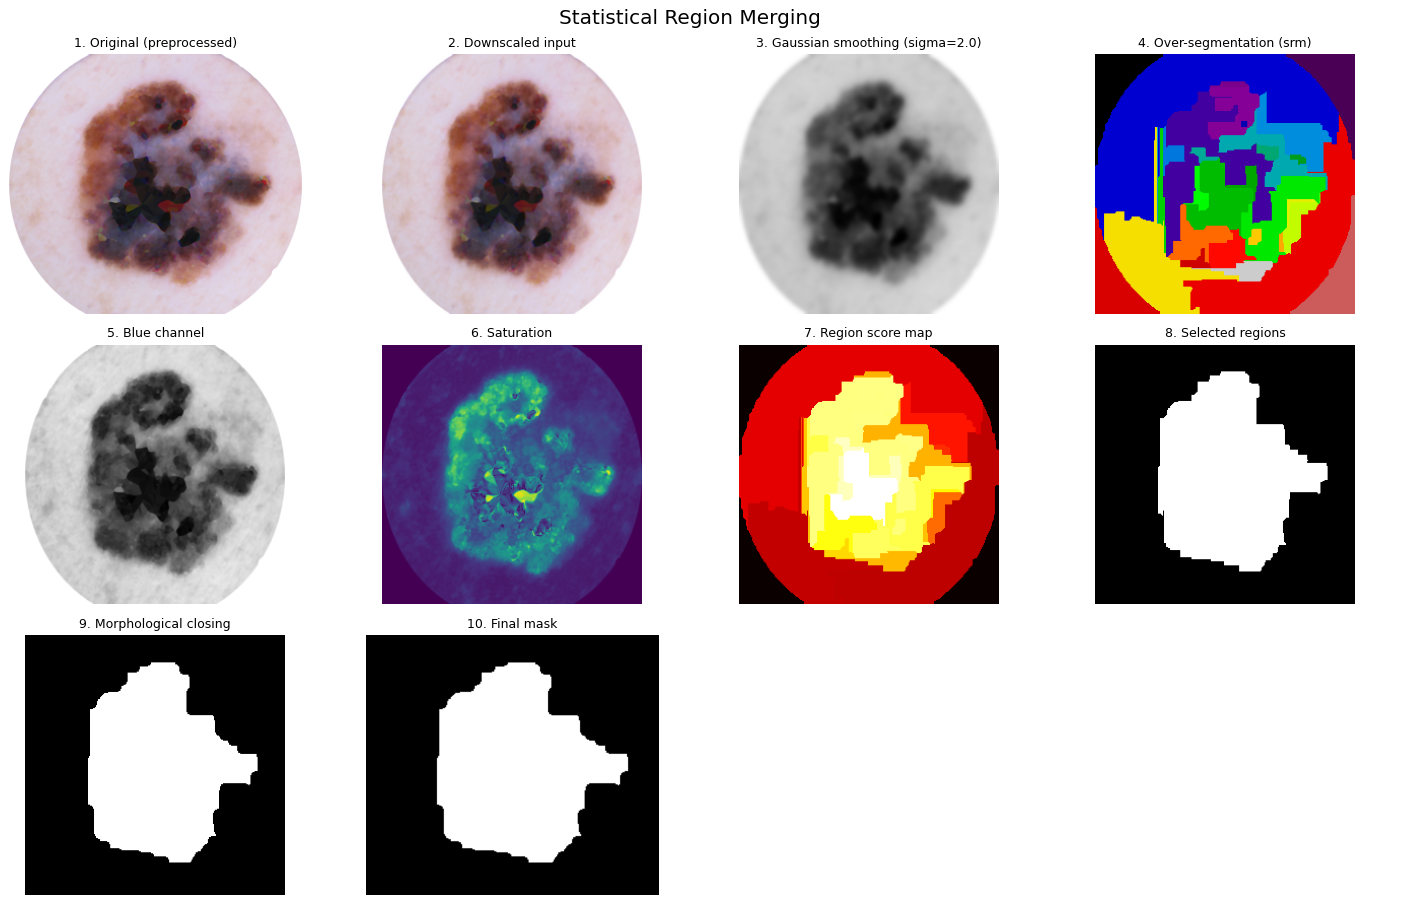

33 regions at Q=25.0


In [6]:
result_srm = region_merging.segment(image, scale=25.0, gaussian_sigma=2.0, backend="srm")
figure = viz.plot_pipeline(result_srm, title="Statistical Region Merging", original=image)
plt.show()

print(f"{result_srm.info['n_regions']} regions at Q={result_srm.info['scale']}")

### Felzenszwalb as a reference point

Felzenszwalb's graph-based segmentation solves a similar over-segmentation
problem much faster. It is a *different* algorithm, so it is reported
separately and never labelled SRM.

In [7]:
result_fz = region_merging.segment(image, scale=25.0, gaussian_sigma=2.0, backend="felzenszwalb")
print(f"SRM          {result_srm.info['n_regions']:3d} regions")
print(f"Felzenszwalb {result_fz.info['n_regions']:3d} regions")

SRM           33 regions
Felzenszwalb  38 regions


## 6. Comparing the three on one image

Each raw mask goes through the same post-processing (hole filling, an
inversion guard, and a convex hull that ignores distant specks of noise), so
the three are compared on equal terms and only the segmentation itself differs.

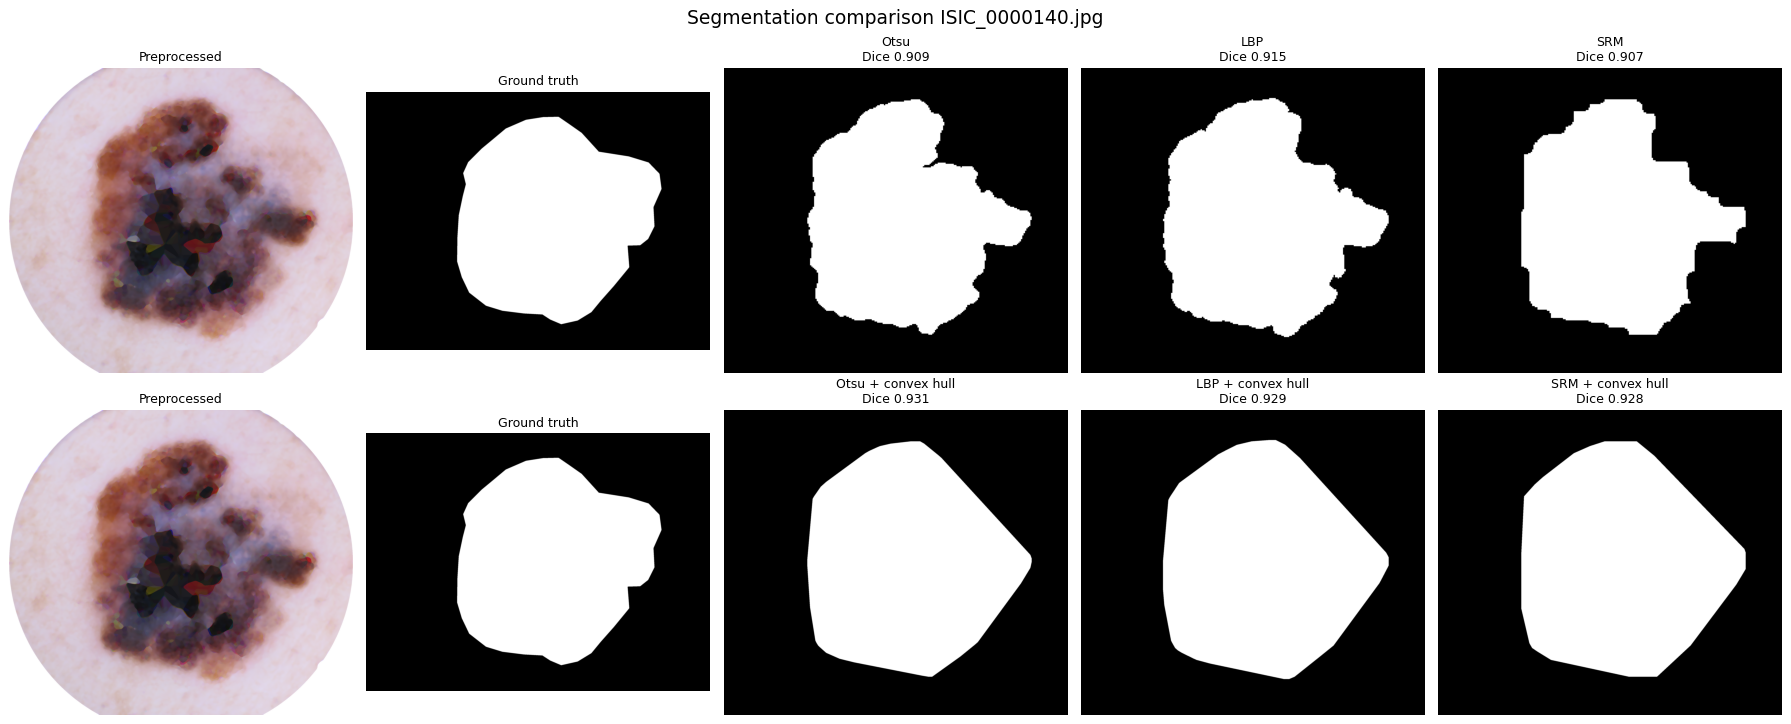

Otsu  Dice 0.909   with convex hull 0.931
LBP   Dice 0.915   with convex hull 0.929
SRM   Dice 0.907   with convex hull 0.928


In [8]:
outcome = run_all_methods(sample, keep_results=True)

figure = viz.plot_comparison(
    outcome.preprocessed,
    sample.ground_truth,
    outcome.masks,
    hulls=outcome.hulls,
    scores=outcome.scores,
    name=sample.name,
)
plt.show()

for method in METHODS:
    raw = outcome.scores[method]
    hull = outcome.scores[f"{method}_Hull"]
    print(f"{method:<5} Dice {raw:.3f}   with convex hull {hull:.3f}")

## 7. Seven bugs found by an audit, before and after their fix

The post-processing steps in Section 6, and the hair removal and
segmentation steps in Sections 2 and 5, are heuristics, and one of the costs
of a heuristic is that it can silently stop doing what it claims to do. An
audit of this codebase found seven cases of exactly that. Six are fixed in
the current code; the seventh, in SRM, turned out to need more than a mask
once its downstream scoring weights are considered, and 7.7 documents why it
is deliberately left as found rather than silently applied. This section
shows each case concretely, with the buggy version kept alongside only for
the comparison.

### 7.1 `clean_mask` was clipping to a guessed disc, not the real valid area

`clean_mask` is meant to drop everything outside the dermoscope disc. The
buggy version guessed that disc from the image's aspect ratio, on *every*
image, including the seventeen of twenty that preprocessing found to have no
frame at all. On those, the guess is pure fiction, and any lesion pixel
outside it is deleted.

`ISIC_0000049` has no frame, and its lesion reaches close to the top-left
corner.

ISIC_0000049.jpg has no frame, so the real valid area is the whole image.
Old clean_mask (guessed disc) erased 20.4% of the true lesion.
Fixed clean_mask (real valid area) erases 0.0%.


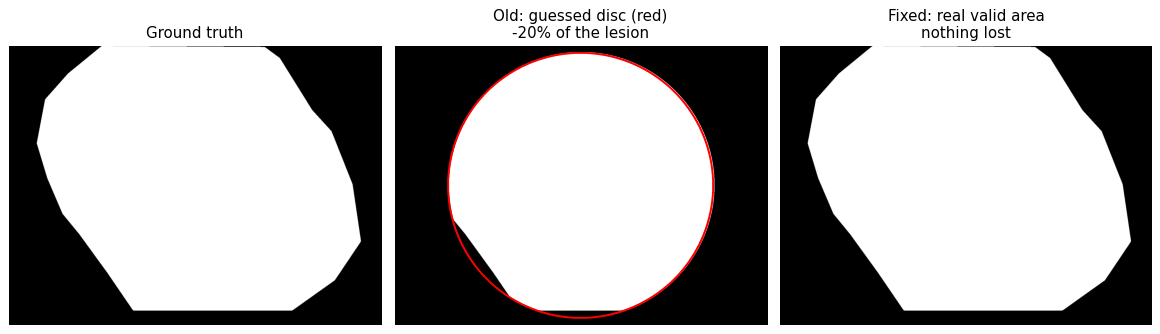

In [9]:
import numpy as np


def guessed_disc_of(mask):
    """The disc clean_mask used to invent from the array shape, before the fix."""
    height, width = mask.shape
    grid_y, grid_x = np.ogrid[:height, :width]
    centre_y, centre_x = height // 2, width // 2
    return (grid_x - centre_x) ** 2 + (grid_y - centre_y) ** 2 <= (
        min(height, width) // 2 * 0.95
    ) ** 2


leak_sample = load_sample(ROOT / "data" / "melanoma" / "ISIC_0000049.jpg")
truth = leak_sample.ground_truth.astype(bool)

# Isolating the clipping step alone, on both sides: this image's lesion covers
# 65% of the frame, well above the 60% inversion threshold, so running it
# through the full clean_mask would also trigger the *second* guard (7.2) and
# confound the two. Comparing the clip in isolation keeps this demonstration
# about the disc guess only.
disc = guessed_disc_of(truth)
old_cleaned = truth & disc  # what the buggy clean_mask kept
real_valid_area = np.ones_like(truth)  # no frame on this image: everything is valid
new_cleaned = truth & real_valid_area

loss = 100 * (1 - old_cleaned.sum() / truth.sum())
print(f"{leak_sample.name} has no frame, so the real valid area is the whole image.")
print(f"Old clean_mask (guessed disc) erased {loss:.1f}% of the true lesion.")
print(f"Fixed clean_mask (real valid area) erases {100 * (1 - new_cleaned.sum() / truth.sum()):.1f}%.")

figure, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(truth, cmap="gray")
axes[0].set_title("Ground truth")
axes[1].imshow(old_cleaned, cmap="gray")
axes[1].contour(disc, [0.5], colors="red", linewidths=1.5)
axes[1].set_title(f"Old: guessed disc (red)\n-{loss:.0f}% of the lesion")
axes[2].imshow(new_cleaned, cmap="gray")
axes[2].set_title("Fixed: real valid area\nnothing lost")
for axis in axes:
    axis.axis("off")
figure.tight_layout()
plt.show()

### 7.2 The inversion guard compared 60% against the wrong denominator

If a segmenter picks skin instead of lesion, the mask covers most of the valid
area, and the guard should flip it back. The buggy version compared that
coverage to the *whole rectangular image*, not to the disc. A dermoscope disc
inscribed in a non-square rectangle covers only about half of it, so a mask
that fills the entire disc still reads as roughly 50-55% of the array: **under
the 60% threshold, on essentially every image in this dataset.** The guard was
not merely miscalibrated, it was very close to unreachable.

This case barely arises on real images (that is exactly the bug: the guard
almost never fires), so it is shown here schematically on a synthetic disc,
the same construction used in the test suite.

coverage of the whole rectangle : 44.2%  (old comparison, under 60% -> never inverts)
coverage of the real valid area : 83.1%  (fixed comparison, over 60% -> inverts)


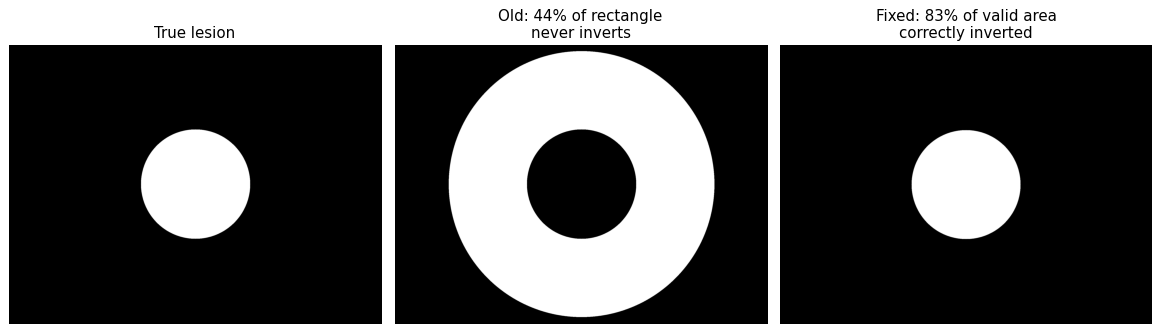

In [10]:
height, width = 1536, 2048  # a real image's proportions from this dataset

grid_y, grid_x = np.ogrid[:height, :width]
centre_y, centre_x = height // 2, width // 2
disc = (grid_x - centre_x) ** 2 + (grid_y - centre_y) ** 2 <= (
    min(height, width) // 2 * 0.95
) ** 2

lesion = (grid_x - centre_x) ** 2 + (grid_y - centre_y) ** 2 <= 300**2
skin_selected = (disc & ~lesion).astype(np.uint8)  # segmenter picked skin, not lesion

old_ratio = skin_selected.sum() / skin_selected.size          # buggy denominator
new_ratio = skin_selected.sum() / disc.sum()                  # fixed denominator

print(f"coverage of the whole rectangle : {old_ratio:.1%}  (old comparison, under 60% -> never inverts)")
print(f"coverage of the real valid area : {new_ratio:.1%}  (fixed comparison, over 60% -> inverts)")

old_result = skin_selected  # old code: 55% < 60%, never triggers, stays wrong
new_result = postprocessing.clean_mask(skin_selected, disc)

figure, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(lesion, cmap="gray")
axes[0].set_title("True lesion")
axes[1].imshow(old_result, cmap="gray")
axes[1].set_title(f"Old: {old_ratio:.0%} of rectangle\nnever inverts")
axes[2].imshow(new_result, cmap="gray")
axes[2].set_title(f"Fixed: {new_ratio:.0%} of valid area\ncorrectly inverted")
for axis in axes:
    axis.axis("off")
figure.tight_layout()
plt.show()

### 7.3 The convex hull's satellite reach grew with the lesion, past the image itself

`smart_convex_hull` is supposed to keep a satellite blob only if it sits close
to the lesion, so a stray speck of noise in a corner cannot stretch the hull
across the whole image. "Close" was defined as *2.5 times the lesion's own
radius*. On a large lesion, that reach can exceed the image: on
`ISIC_0000145`, it worked out to 1376 px, while the farthest corner of the
image sits at only 1328 px. Every pixel counted as close, so the filter had
nothing left to reject. The fix measures the reach against the image diagonal
instead, so it cannot grow past the image.

old hull covers 39.9% of the image
new hull covers 31.7% of the image


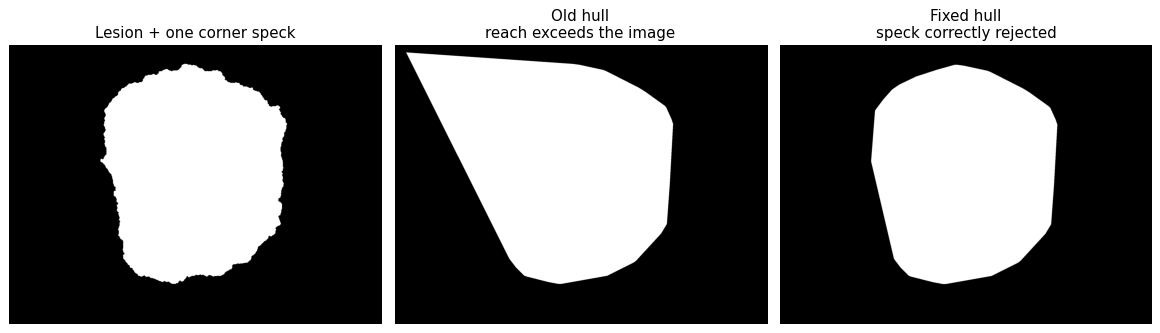

In [11]:
from skimage.measure import label, regionprops
from skimage.morphology import convex_hull_image


def old_smart_hull(mask, distance_radii=2.5, area_ratio=0.03):
    """smart_convex_hull before the fix: reach relative to the lesion's own radius."""
    labelled = label(mask)
    regions = regionprops(labelled)
    main = max(regions, key=lambda region: region.area)
    main_centroid = np.array(main.centroid)
    main_radius = np.sqrt(main.area / np.pi)

    kept = labelled == main.label
    for region in regions:
        if region.label == main.label:
            continue
        large_enough = region.area / main.area > area_ratio
        close_enough = (
            np.linalg.norm(np.array(region.centroid) - main_centroid) < main_radius * distance_radii
        )
        if large_enough or close_enough:
            kept |= labelled == region.label
    return convex_hull_image(kept).astype(np.uint8)


speck_sample = load_sample(ROOT / "data" / "melanoma" / "ISIC_0000145.jpg")
lesion = speck_sample.ground_truth.astype(np.uint8)
height, width = lesion.shape

with_speck = lesion.copy()
with_speck[int(height * 0.03), int(width * 0.03)] = 1  # one pixel, far corner

old_hull = old_smart_hull(with_speck)
new_hull = postprocessing.smart_convex_hull(with_speck)

print(f"old hull covers {100 * old_hull.mean():.1f}% of the image")
print(f"new hull covers {100 * new_hull.mean():.1f}% of the image")

figure, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(with_speck, cmap="gray")
axes[0].set_title("Lesion + one corner speck")
axes[1].imshow(old_hull, cmap="gray")
axes[1].set_title("Old hull\nreach exceeds the image")
axes[2].imshow(new_hull, cmap="gray")
axes[2].set_title("Fixed hull\nspeck correctly rejected")
for axis in axes:
    axis.axis("off")
figure.tight_layout()
plt.show()

### 7.4 A satellite kept for being large had no distance limit at all

The reach fixed in 7.3 only applied to a satellite kept for being *close*. One
kept for being *large* (more than 3% of the lesion's own area) was exempt from
any distance check, on the assumption that a sizeable second lobe of the same
lesion should count regardless of where it sits.

Fixing 7.1 let raw masks reach this code path for the first time on unframed
images, and exposed why that assumption fails: on `ISIC_0000095`, LBP's
texture criterion also flags several patches of scaly skin scattered across
the image, unrelated to the lesion. The largest weighs 34% of the main
region's own area and sits 972 px away, so the old rule kept it, and several
smaller ones, no matter how far away they were.

ISIC_0000095.jpg: LBP raw mask, 16.1% of the image
old hull (size exemption) Dice: 0.189
fixed hull (distance only) Dice: 0.694


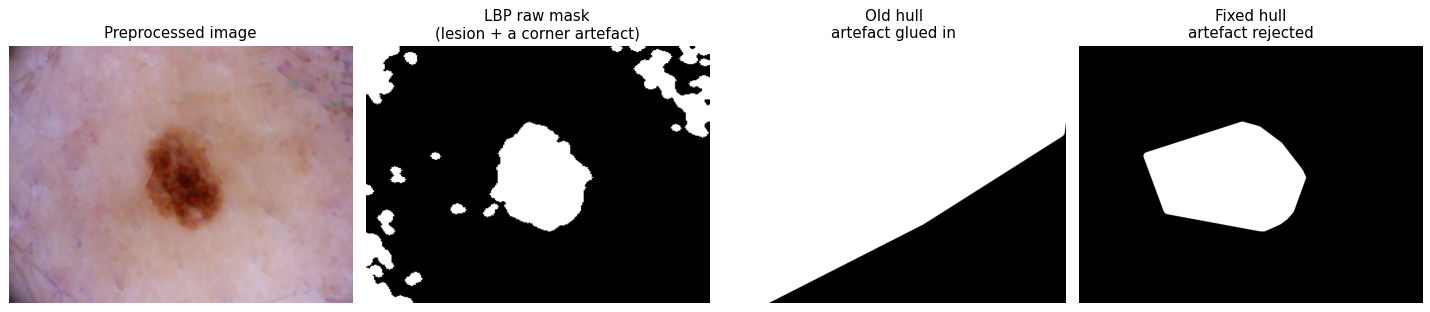

In [12]:
def old_smart_hull_with_size_exemption(mask, distance_fraction=0.25, area_ratio=0.03):
    """smart_convex_hull with the size exemption, before it was removed."""
    labelled = label(mask)
    regions = regionprops(labelled)
    main = max(regions, key=lambda region: region.area)
    main_centroid = np.array(main.centroid)
    reach = np.hypot(*mask.shape) * distance_fraction

    kept = labelled == main.label
    for region in regions:
        if region.label == main.label:
            continue
        large_enough = region.area / main.area > area_ratio
        close_enough = np.linalg.norm(np.array(region.centroid) - main_centroid) < reach
        if large_enough or close_enough:  # the bug: size alone was enough
            kept |= labelled == region.label
    return convex_hull_image(kept).astype(np.uint8)


artefact_sample = load_sample(ROOT / "data" / "nevus" / "ISIC_0000095.jpg")
artefact_image, artefact_valid = preprocess_with_mask(artefact_sample.image)
artefact_result = lbp.segment(artefact_image, sigma=3.0, valid_mask=artefact_valid)
artefact_final = postprocessing.clean_mask(artefact_result.mask, artefact_valid)
artefact_final = np.asarray(artefact_final)
from scipy.ndimage import binary_fill_holes

artefact_final = binary_fill_holes(artefact_final).astype(np.uint8)

old_hull = old_smart_hull_with_size_exemption(artefact_final)
new_hull = postprocessing.smart_convex_hull(artefact_final)

from dermoseg.metrics import dice_score

print(f"{artefact_sample.name}: LBP raw mask, {artefact_final.mean():.1%} of the image")
print(f"old hull (size exemption) Dice: {dice_score(old_hull, artefact_sample.ground_truth):.3f}")
print(f"fixed hull (distance only) Dice: {dice_score(new_hull, artefact_sample.ground_truth):.3f}")

figure, axes = plt.subplots(1, 4, figsize=(16, 4.5))
axes[0].imshow(artefact_image)
axes[0].set_title("Preprocessed image")
axes[1].imshow(artefact_final, cmap="gray")
axes[1].set_title("LBP raw mask\n(lesion + a corner artefact)")
axes[2].imshow(old_hull, cmap="gray")
axes[2].set_title("Old hull\nartefact glued in")
axes[3].imshow(new_hull, cmap="gray")
axes[3].set_title("Fixed hull\nartefact rejected")
for axis in axes:
    axis.axis("off")
figure.tight_layout()
plt.show()

### 7.5 Hair removal only tested two of the four orientations

The docstring for this step used to claim that a horizontal and a vertical
structuring element "catch hairs at any orientation". They do not: a hair
running near 45° gets little benefit from either, the same way a horizontal
element barely helps against a strictly vertical hair. DullRazor itself closes
at four orientations for this reason.

Two diagonal structuring elements close the gap, sized so their own diagonal
length matches the axis-aligned ones. The effect holds on every image in this
dataset, not just a contrived one: re-running detection with all four
orientations flags more hair pixels than the two-orientation version on all
twenty images, from a few percent more up to 30% more.

ISIC_0000140.jpg
hair pixels, horizontal + vertical only : 142,743
hair pixels, all four orientations      : 175,071
pixels only the diagonal elements caught:  32,328 (+22.6%)


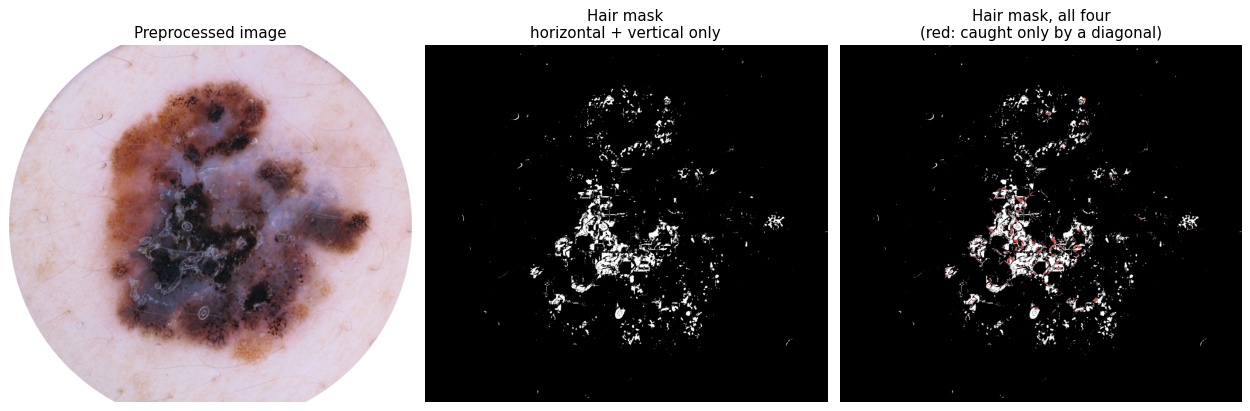

In [13]:
from skimage import morphology as morph
from dermoseg import preprocessing
from dermoseg.preprocessing import isolate_dermoscope_circle

HAIR_LENGTH, HAIR_WIDTH, HAIR_THRESHOLD = 50, 10, 40


def old_hair_response(channel):
    """The horizontal + vertical closing only, before the diagonal fix."""
    h = morph.closing(channel, footprint=np.ones((HAIR_LENGTH, HAIR_WIDTH), dtype=bool))
    v = morph.closing(channel, footprint=np.ones((HAIR_WIDTH, HAIR_LENGTH), dtype=bool))
    return np.maximum(h, v)


hair_image, _ = isolate_dermoscope_circle(sample.image, crop=True)
red_channel = hair_image[..., 0].astype(float)

old_response = old_hair_response(red_channel)
new_response = preprocessing._directional_closing_max(red_channel)  # 4 orientations

old_hair_mask = np.abs(red_channel - old_response) > HAIR_THRESHOLD
new_hair_mask = np.abs(red_channel - new_response) > HAIR_THRESHOLD
diagonal_only = new_hair_mask & ~old_hair_mask

print(f"{sample.name}")
print(f"hair pixels, horizontal + vertical only : {old_hair_mask.sum():>7,}")
print(f"hair pixels, all four orientations      : {new_hair_mask.sum():>7,}")
print(f"pixels only the diagonal elements caught: {diagonal_only.sum():>7,} "
      f"(+{100 * diagonal_only.sum() / old_hair_mask.sum():.1f}%)")

figure, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(hair_image)
axes[0].set_title("Preprocessed image")
axes[1].imshow(old_hair_mask, cmap="gray")
axes[1].set_title("Hair mask\nhorizontal + vertical only")
axes[2].imshow(new_hair_mask, cmap="gray")
axes[2].imshow(np.ma.masked_where(~diagonal_only, diagonal_only), cmap="autumn", alpha=0.8)
axes[2].set_title("Hair mask, all four\n(red: caught only by a diagonal)")
for axis in axes:
    axis.axis("off")
figure.tight_layout()
plt.show()

### 7.6 The coverage gate summed a raw intensity difference, and compared it to a threshold built for a fraction

The gate that decides whether an image is hairy enough to inpaint is meant to
measure a pixel fraction: "if the eroded hair mask covers less than a few
percent of the valid area, leave the image alone." The buggy version instead
eroded the *raw, unthresholded* intensity difference and summed it directly,
a quantity on a completely different scale from a fraction, then compared
that sum to the same constant anyway. Its decisions barely tracked how much
hair was actually present.

The fix erodes the mask `detect_hair` already builds (thresholded, then
dilated) instead: a lone thin hair line, however long, cannot survive a
disc(12) erosion, only a genuinely extended patch can, so what survives is a
real measure of how much the inpainting below would touch.

ISIC_0000030.jpg
old (buggy sum) ratio : 0.319  (compared against 0.2 -> remove)
new (pixel fraction)  : 0.0029  (compared against 0.03 -> skip)


SRM Dice, correctly left alone: 0.724
SRM Dice, wrongly inpainted   : 0.600  (-0.124)


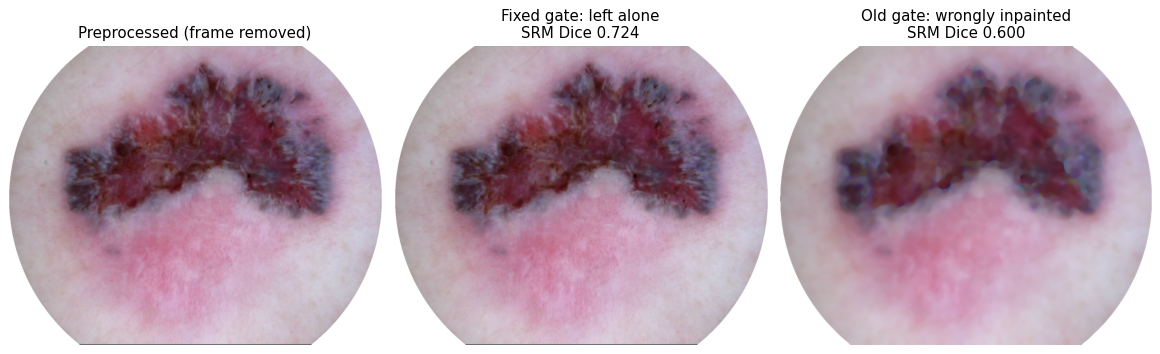

In [14]:
from skimage import filters, morphology as morph2
from dermoseg.preprocessing import (
    detect_hair,
    _inpaint_channel,
    HAIR_COVERAGE_THRESHOLD,
    HAIR_DILATION_SIZE,
)
from dermoseg.metrics import dice_score


def old_coverage_ratio(image, valid):
    """The buggy gate: sum of a raw intensity difference, not a pixel fraction."""
    _, red_response = detect_hair(image)
    raw_diff = np.abs(image[..., 0].astype(float) - red_response)
    eroded = morph2.erosion(raw_diff, footprint=morph2.disk(12))
    return eroded.sum() / valid.sum()


def new_coverage_ratio(image, valid):
    """The fix: erode the already-thresholded, dilated hair mask instead."""
    hair_masks, _ = detect_hair(image)
    eroded = morph2.erosion(hair_masks[..., 0], footprint=morph2.disk(12))
    return eroded.sum() / valid.sum()


def force_remove_hair(image):
    """remove_hair's inpainting, bypassing the coverage gate entirely."""
    hair_masks, _ = detect_hair(image)
    smoothing = np.ones((HAIR_DILATION_SIZE, HAIR_DILATION_SIZE), dtype=bool)
    result = image.copy()
    for channel_index in range(3):
        inpainted = _inpaint_channel(image[..., channel_index], hair_masks[..., channel_index])
        result[..., channel_index] = filters.median(inpainted, smoothing)
    return result


wrong_sample = load_sample(ROOT / "data" / "melanoma" / "ISIC_0000030.jpg")
wrong_image, wrong_valid = isolate_dermoscope_circle(wrong_sample.image, crop=True)
wrong_valid = wrong_valid > 0

old_ratio = old_coverage_ratio(wrong_image, wrong_valid)
new_ratio = new_coverage_ratio(wrong_image, wrong_valid)
print(f"{wrong_sample.name}")
print(f"old (buggy sum) ratio : {old_ratio:.3f}  (compared against 0.2 -> remove)")
print(f"new (pixel fraction)  : {new_ratio:.4f}  (compared against {HAIR_COVERAGE_THRESHOLD} -> skip)")

correct_image, _ = preprocess_with_mask(wrong_sample.image)
forced_image = force_remove_hair(wrong_image)

r_correct = region_merging.segment(correct_image, scale=25.0, gaussian_sigma=2.0, backend="srm")
r_forced = region_merging.segment(forced_image, scale=25.0, gaussian_sigma=2.0, backend="srm")
m_correct = postprocessing.clean_mask(r_correct.mask, wrong_valid)
m_forced = postprocessing.clean_mask(r_forced.mask, wrong_valid)
d_correct = dice_score(m_correct, wrong_sample.ground_truth)
d_forced = dice_score(m_forced, wrong_sample.ground_truth)
print(f"SRM Dice, correctly left alone: {d_correct:.3f}")
print(f"SRM Dice, wrongly inpainted   : {d_forced:.3f}  ({d_forced - d_correct:+.3f})")

figure, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(wrong_image)
axes[0].set_title("Preprocessed (frame removed)")
axes[1].imshow(correct_image)
axes[1].set_title(f"Fixed gate: left alone\nSRM Dice {d_correct:.3f}")
axes[2].imshow(forced_image)
axes[2].set_title(f"Old gate: wrongly inpainted\nSRM Dice {d_forced:.3f}")
for axis in axes:
    axis.axis("off")
figure.tight_layout()
plt.show()


### 7.7 Otsu inherited LBP's blind spot to the frame corners. So did SRM, but fixing it needs more than a mask

Section 4's caveat about LBP applies just as much to the other two methods,
and only LBP was actually guarded against it: frame removal whitens the
corners outside the dermoscope disc, and any method that fits a global
statistic over the whole image reads those synthetic pixels as real data.
Otsu's per-channel `threshold_otsu` sees them as a third, artificially bright
cluster; SRM's region scoring reads its "skin" reference off a band along the
image border, which after cropping still grazes a sliver of frame in each
corner.

Restricting Otsu's threshold to the valid pixels is a direct, contained fix.
Doing the same for SRM's border reference is not: the numbers below show why
it was investigated and deliberately left out of the pipeline instead.

In [15]:
frame_sample = load_sample(ROOT / "data" / "melanoma" / "ISIC_0000030.jpg")
frame_image, frame_valid = preprocess_with_mask(frame_sample.image)
print(f"{frame_sample.name}: {100 * (1 - frame_valid.mean()):.0f}% of the crop is still frame")

r_otsu_unmasked = otsu.segment(frame_image)
r_otsu_masked = otsu.segment(frame_image, valid_mask=frame_valid)
d_otsu_unmasked = dice_score(postprocessing.clean_mask(r_otsu_unmasked.mask, frame_valid), frame_sample.ground_truth)
d_otsu_masked = dice_score(postprocessing.clean_mask(r_otsu_masked.mask, frame_valid), frame_sample.ground_truth)

print("\nOtsu")
print("thresholds, frame included:", {k: round(v, 3) for k, v in r_otsu_unmasked.info["thresholds"].items()})
print("thresholds, frame excluded:", {k: round(v, 3) for k, v in r_otsu_masked.info["thresholds"].items()})
print(f"Dice, frame included: {d_otsu_unmasked:.4f}")
print(f"Dice, frame excluded: {d_otsu_masked:.4f}  (the fix: a real bias removed, for a small change here)")


ISIC_0000030.jpg: 12% of the crop is still frame



Otsu
thresholds, frame included: {'red': 0.601, 'green': 0.503, 'blue': 0.534}
thresholds, frame excluded: {'red': 0.576, 'green': 0.451, 'blue': 0.5}
Dice, frame included: 0.6726
Dice, frame excluded: 0.6670  (the fix: a real bias removed, for a small change here)


SRM's border-sampled skin reference tells a more cautionary story. The
reference intensity and saturation are read straight off the crop's border,
and on a framed image most of that border is still whitened corner, not skin.

In [16]:
from dermoseg.segmentation.base import downscale, downscale_mask
from dermoseg.segmentation.region_merging import SKIN_PERCENTILE
from skimage.color import rgb2gray, rgb2hsv
from skimage.filters import gaussian as sk_gaussian

small = downscale(frame_image)
valid_small = downscale_mask(frame_valid)
intensity, saturation = small[..., 2], rgb2hsv(small)[..., 1]


def border_values(array, valid=None):
    band = np.concatenate([array[0, :], array[-1, :], array[:, 0], array[:, -1]])
    if valid is None:
        return band
    valid_band = np.concatenate([valid[0, :], valid[-1, :], valid[:, 0], valid[:, -1]])
    return band[valid_band]


print("skin reference, frame included:",
      "intensity", round(float(np.percentile(border_values(intensity), SKIN_PERCENTILE)), 3),
      "saturation", round(float(np.median(border_values(saturation))), 3))
print("skin reference, frame excluded:",
      "intensity", round(float(np.percentile(border_values(intensity, valid_small), SKIN_PERCENTILE)), 3),
      "saturation", round(float(np.median(border_values(saturation, valid_small))), 3))

r_srm_unmasked = region_merging.segment(frame_image, scale=25.0, gaussian_sigma=2.0, backend="srm")
r_srm_masked = region_merging.segment(frame_image, scale=25.0, gaussian_sigma=2.0, backend="srm", valid_mask=frame_valid)
d_srm_unmasked = dice_score(postprocessing.clean_mask(r_srm_unmasked.mask, frame_valid), frame_sample.ground_truth)
d_srm_masked = dice_score(postprocessing.clean_mask(r_srm_masked.mask, frame_valid), frame_sample.ground_truth)
print(f"\nSRM Dice, frame included (what the pipeline uses): {d_srm_unmasked:.4f}")
print(f"SRM Dice, frame excluded (the 'more correct' input): {d_srm_masked:.4f}")


skin reference, frame included: intensity 1.0 saturation 0.0
skin reference, frame excluded: intensity 0.418 saturation 0.058



SRM Dice, frame included (what the pipeline uses): 0.7240
SRM Dice, frame excluded (the 'more correct' input): 0.5104


The frame-excluded reference (intensity around 0.42, saturation around
0.06) is the real skin tone: the frame-included one sits at intensity 1.0
and saturation 0.0, the whitened corners themselves, not skin at all. And
yet the "more correct" reference scores *lower* here, not higher.

The reason is that `WEIGHT_CONTRAST`, `WEIGHT_SATURATION`, `MIN_CONTRAST`,
`MIN_SATURATION_DIFF` and `SCORE_KEEP_RATIO` in `region_merging.py` were all
tuned by hand against scores computed relative to the *biased* reference.
Swapping in the unbiased one changes the scale those scores live on without
retuning the thresholds that judge them, which measurably hurts Dice on this
dataset's framed images rather than helping. `region_merging.segment` keeps
`valid_mask` as a parameter, correct and tested in isolation
(`tests/test_region_merging.py`), but `dermoseg.pipeline.METHODS` does not
pass it: fixing the reference properly means retuning the scoring weights
alongside it, which is out of scope here. Shipping a "more correct" input
into a hand-tuned system built around the old, biased one is exactly the
kind of silent mismatch this audit exists to catch, not to introduce.

## 8. Results over the whole dataset

The table below is produced by `scripts/run_benchmark.py`, which runs the same
`run_all_methods` used above over all twenty images, including the seven cases
from Section 7. LBP and SRM are seeded and reproduce exactly on re-running.
Otsu's Chan-Vese refinement has a small non-determinism of its own (a handful
of boundary pixels can flip between runs), moving its Dice by up to about
0.0002 — never enough to change a number at the precision reported here.

In [17]:
results = pd.read_csv(ROOT / "reports" / "per_image_results.csv")
columns = [name for method in METHODS for name in (method, f"{method}_Hull")]

print("Mean Dice per category")
print(results.groupby("Category")[columns].mean().round(3).to_string())
print("\nMean Dice overall")
print(results[columns].mean().round(3).to_string())

Mean Dice per category
           Otsu  Otsu_Hull    LBP  LBP_Hull    SRM  SRM_Hull
Category                                                    
melanoma  0.820      0.873  0.844     0.893  0.795     0.850
nevus     0.856      0.907  0.844     0.907  0.856     0.893

Mean Dice overall
Otsu         0.838
Otsu_Hull    0.890
LBP          0.844
LBP_Hull     0.900
SRM          0.826
SRM_Hull     0.872


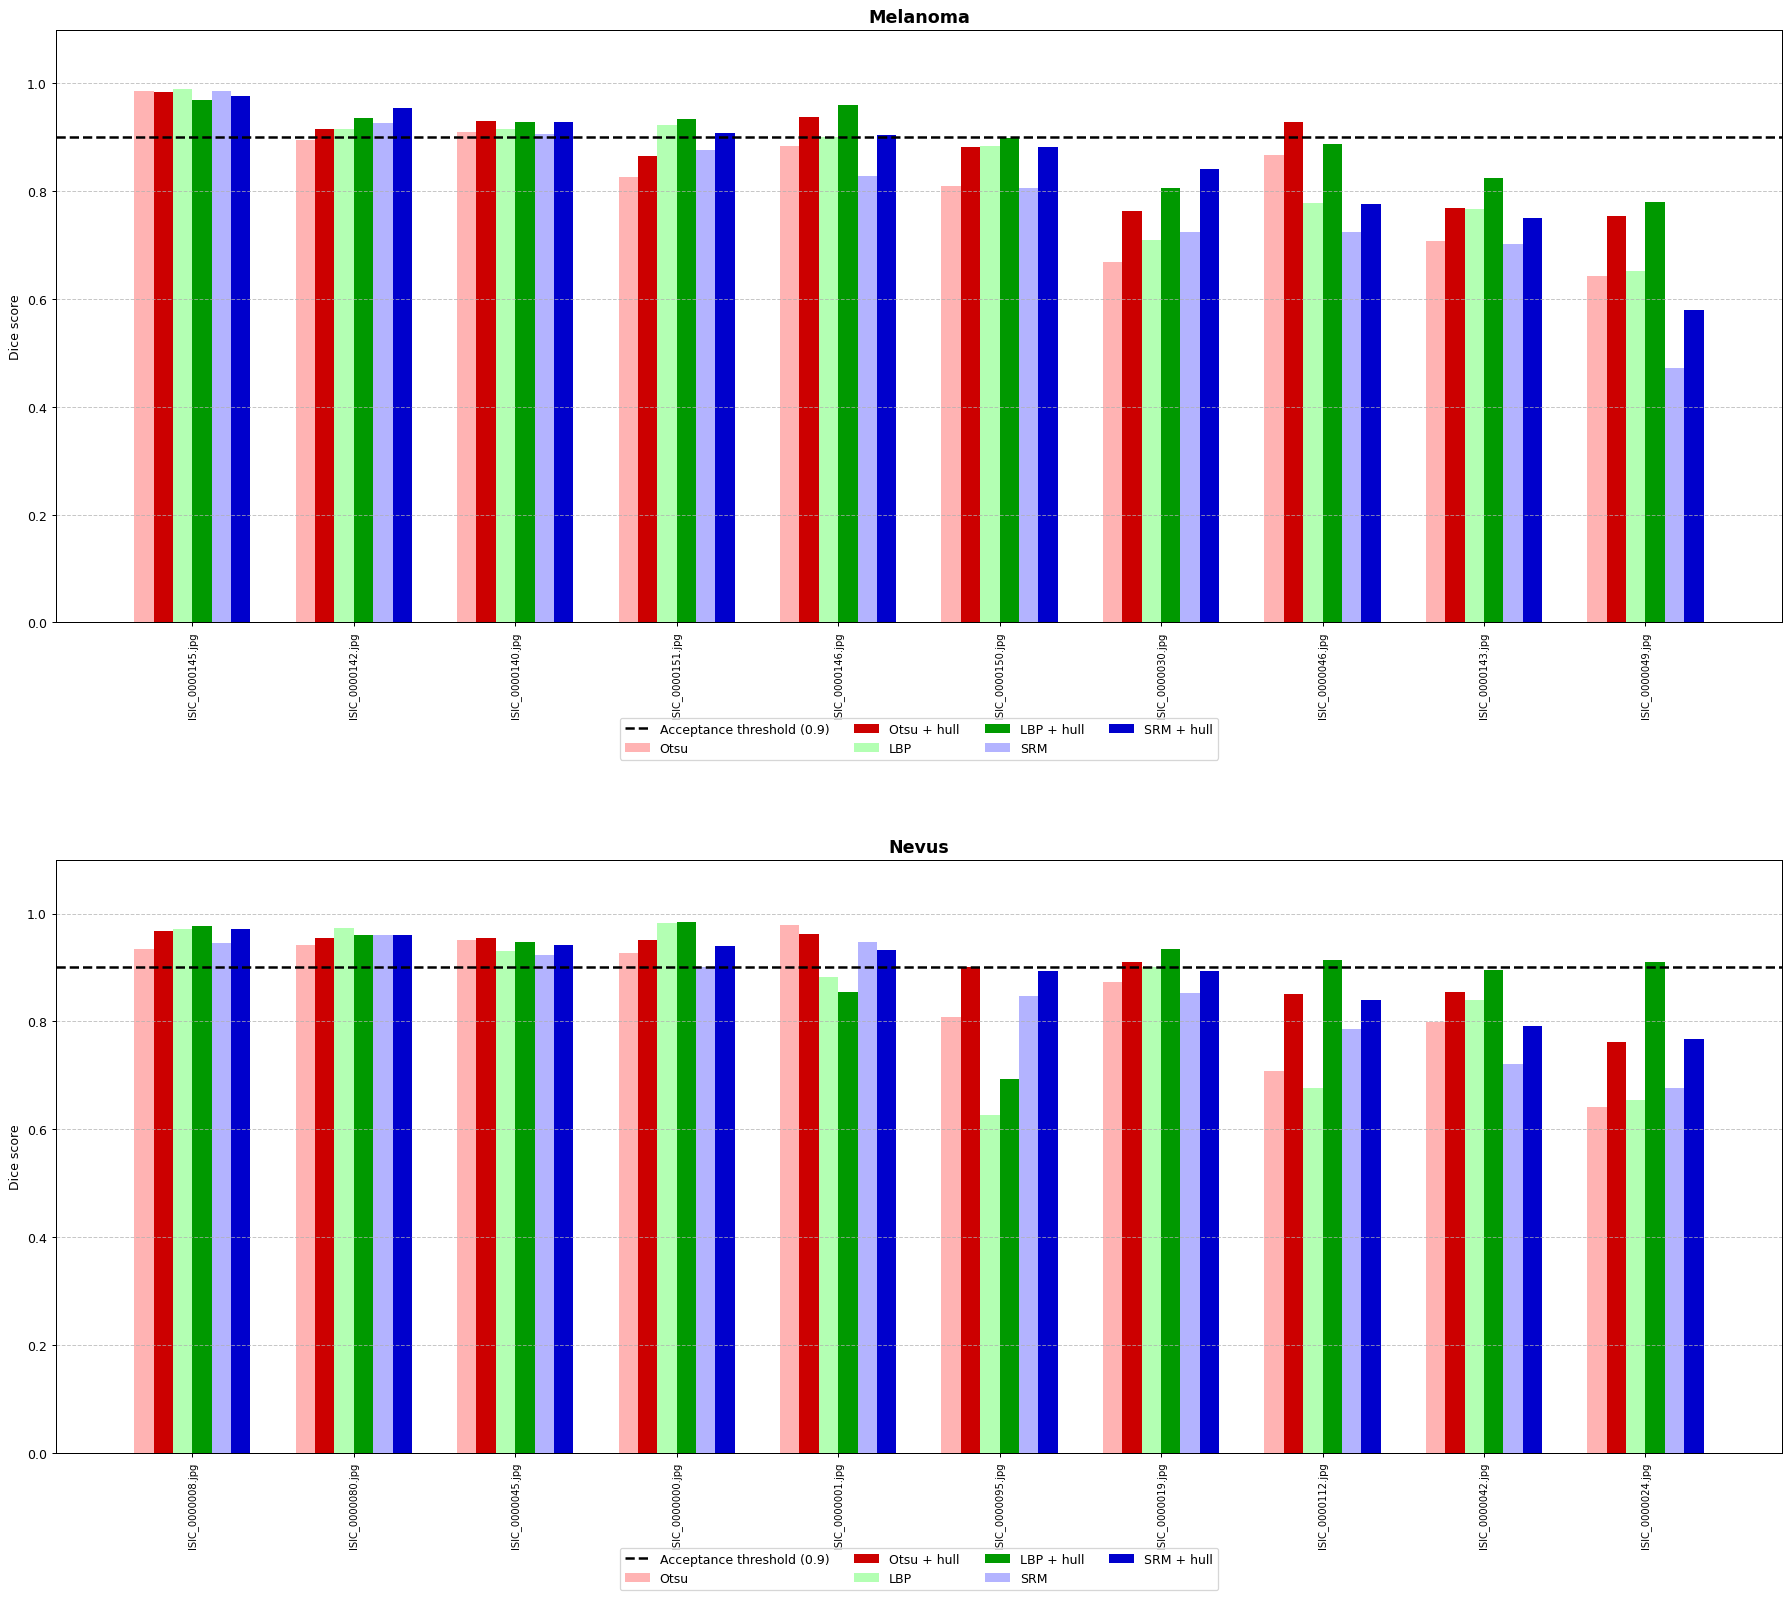

In [18]:
figure, axes = plt.subplots(2, 1, figsize=(20, 18))
viz.plot_dice_per_image(results[results.Category == "melanoma"], "Melanoma", axes[0])
viz.plot_dice_per_image(results[results.Category == "nevus"], "Nevus", axes[1])
figure.tight_layout()
figure.subplots_adjust(bottom=0.1, hspace=0.4)
plt.show()

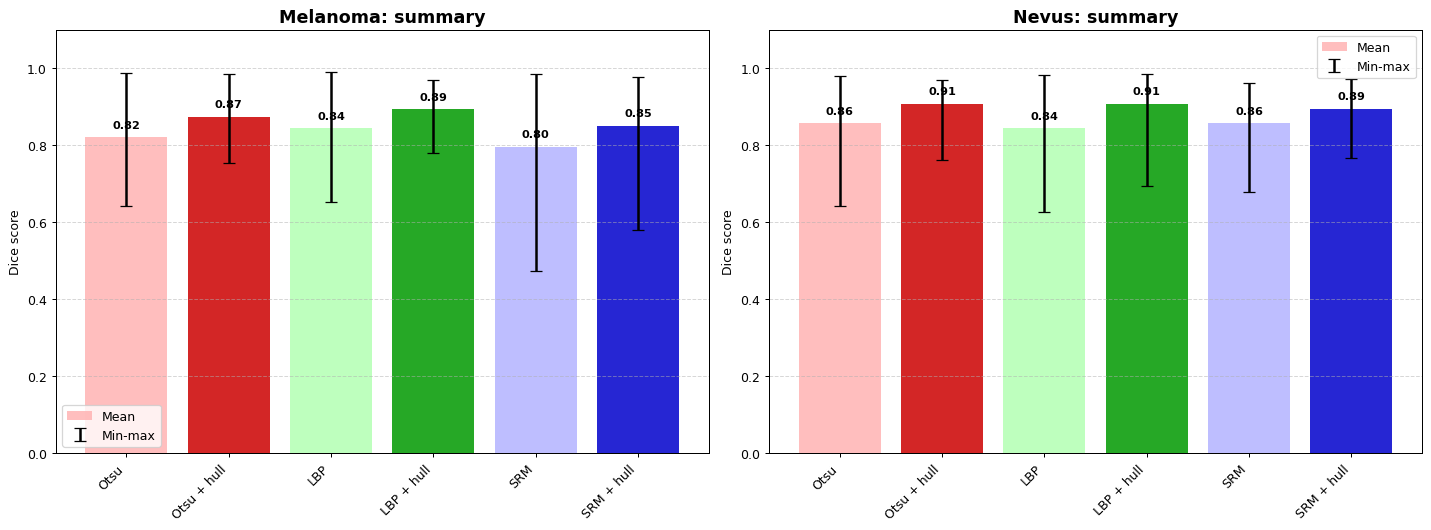

In [19]:
figure, axes = plt.subplots(1, 2, figsize=(16, 6))
viz.plot_summary_stats(results[results.Category == "melanoma"], "Melanoma: summary", axes[0])
viz.plot_summary_stats(results[results.Category == "nevus"], "Nevus: summary", axes[1])
figure.tight_layout()
plt.show()

## 9. What the numbers say

**LBP Clustering gives the best raw masks** (mean Dice 0.844), narrowly ahead
of Otsu (0.838) and SRM (0.826). The margin is smaller than an earlier version
of this project reported, because fixing the seven cases in Section 7 shifts
every method's raw score, not just the hull.

**The convex hull helps all three methods by a similar amount**, about +0.046
to +0.056 Dice on average, including LBP: its masks are not as reliably
already-connected as we first assumed. **LBP with the hull is the best result
overall (0.900)**, ahead of Otsu+hull (0.890) and SRM+hull (0.872). The hull is
not a free lunch everywhere: on three images whose raw mask was already
excellent (Dice above 0.88) - ISIC_0000001, ISIC_0000145 and ISIC_0000080 -
it costs LBP a small amount, up to 0.027 Dice, by adding convexity to a mask
that didn't need it.

**Melanomas are harder than nevi** for all three methods, which is the
clinically expected direction: melanoma borders are irregular and poorly
defined by definition, and that is precisely what the ABCD rule looks for.

**The failures are informative.** ISIC_0000024 and ISIC_0000049 drag every
method's raw mask down (all under 0.70). The hull recovers that unevenly:
LBP climbs back to 0.78-0.91, Otsu to the mid-0.70s, and SRM as low as 0.58.
Both are low-contrast lesions where no intensity or texture cue cleanly
separates lesion from skin. These are the cases a learned model would handle
better, and they mark the honest limit of the classical approach.